In [1]:
import cv2
import math
import numpy as np
import matplotlib.pyplot as plt
from numba import njit

In [2]:
def display_image_grayscale(im):
  plt.imshow(im, cmap='gray', vmin=0, vmax=255)
  plt.axis('off')
  plt.show()

def display_image_color(im):
  plt.imshow(im)
  plt.axis('off')
  plt.show()


In [3]:
def create_gaussian_kernel(L, sigma):
    if L % 2 == 0 or L <= 0:
        print("Kernel size must be an odd integer")
        return None
    midpoint = L // 2
    kernel = [[0 for _ in range(L)] for _ in range(L)]
    total = 0
    for i in range(L):
        for j in range(L):
            y = (i - midpoint)
            x = (j - midpoint)
            value = (1/(2*math.pi*sigma**2)) * math.exp(-(x**2 + y**2)/(2*sigma**2))
            kernel[i][j] = value
            total += value
    for i in range(L):
        for j in range(L):
            kernel[i][j] /= total # Normalization
    return np.array(kernel)

In [4]:
@njit
def _apply_kernel(im_padded, kernel, padding_size):
    N, M = im_padded.shape
    im_filtered = np.zeros_like(im_padded)

    for i in range(padding_size, N - padding_size):
        for j in range(padding_size, M - padding_size):
            # Explicit slicing for Numba compatibility
            im_window = im_padded[i-padding_size : i+padding_size+1, j-padding_size : j+padding_size+1]
            newPixel = np.sum(im_window * kernel)
            im_filtered[i, j] = newPixel
    return im_filtered

'''
This function is a general image filter that works for various kernels
'''
def image_filter(im, kernel):
    def convolution(im, kernel):
        L = len(kernel)
        padding_size = (L - 1) // 2
        im_padded = np.pad(im, pad_width=padding_size, mode='edge').astype(np.float32)
        im_filtered = _apply_kernel(im_padded, kernel, padding_size)
        im_filtered = im_filtered[padding_size: -padding_size, padding_size: -padding_size]
        return np.clip(im_filtered, 0, 255).astype(np.uint8)
    
    if len(kernel) % 2 == 0 or len(kernel) <= 0:
        print("Kernel size must be an odd integer")
        return None

    if len(im.shape) == 3: # RGB/BGR images
        channels = [convolution(im[:, :, i], kernel) for i in range(3)]
        return np.dstack(channels)
    else:
        return convolution(im, kernel)

In [5]:
@njit
def _apply_median_kernel(im_padded, L, padding_size):
    N, M = im_padded.shape
    im_filtered = np.zeros_like(im_padded)
    for i in range(padding_size, N-padding_size):
        for j in range(padding_size, M-padding_size):
            median = np.median(im_padded[i-padding_size : i+padding_size+1, j-padding_size : j+padding_size+1])
            im_filtered[i, j] = median
    return im_filtered

'''
Non-linear filter used for calculating the median value in a kernel. Useful for removing salt and pepper noise
'''
def median_filter(im, L):
    if L % 2 == 0 or L <= 0:
        print("Kernel size must be an odd integer")
        return None
    if len(im.shape) == 2: # only grayscale images
        padding_size = (L-1) // 2
        im_padded = np.pad(im, pad_width=padding_size, mode='edge').astype(np.float32)
        im_filtered = _apply_median_kernel(im_padded, L, padding_size)
        return np.clip(im_filtered[padding_size: -padding_size, padding_size: -padding_size], 0, 255).astype(np.uint8)
    

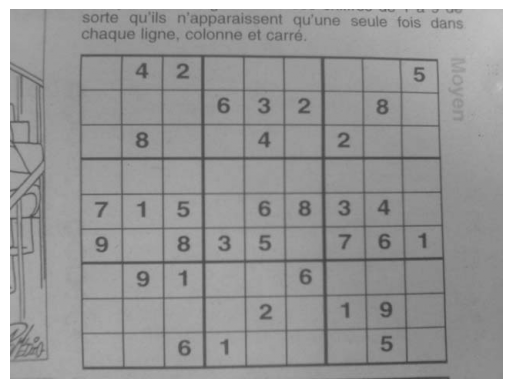

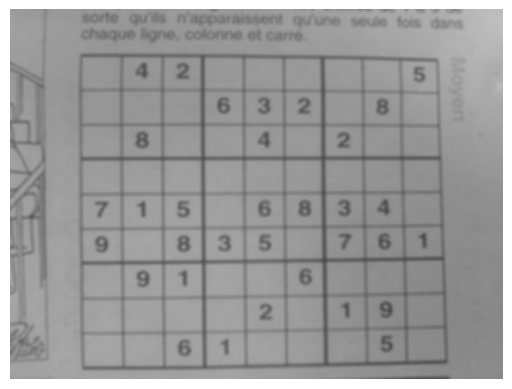

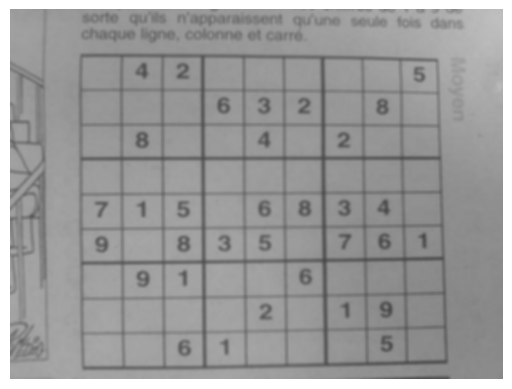

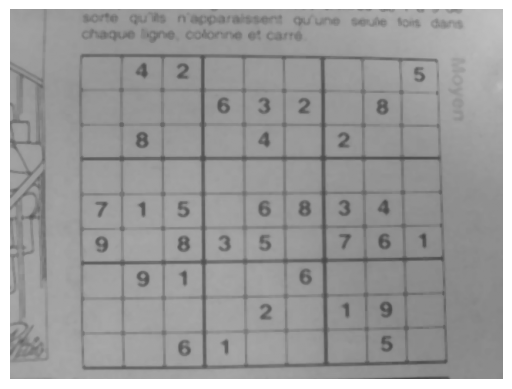

In [6]:
# Create a kernel which is a L by L array where each value is 1/(L^2)
image = cv2.imread("images/image10.jpg", cv2.IMREAD_GRAYSCALE)
L = 5
box_kernel = np.ones((L, L)) / (L**2)
gaussian_kernel = create_gaussian_kernel(L, 3)

blurred_image = image_filter(image, box_kernel)
median_filter_image = median_filter(image, L)
gaussian_image = image_filter(image, gaussian_kernel)
display_image_grayscale(image)
display_image_grayscale(blurred_image)
display_image_grayscale(gaussian_image)
display_image_grayscale(median_filter_image)


In [19]:
def threshold(im, thresh_val):
    
    if (len(im.shape) != 2 or thresh_val <= 0 or thresh_val > 255):
        print("Image must be grayscale and threshold value must be between 1-255")
        return None
    thresh_im = im.copy()
    for i in range(len(im)):
        for j in range(len(im[0])):
            if thresh_im[i][j] >= thresh_val:
                thresh_im[i][j] = 255
            else:
                thresh_im[i][j] = 0
    return thresh_im

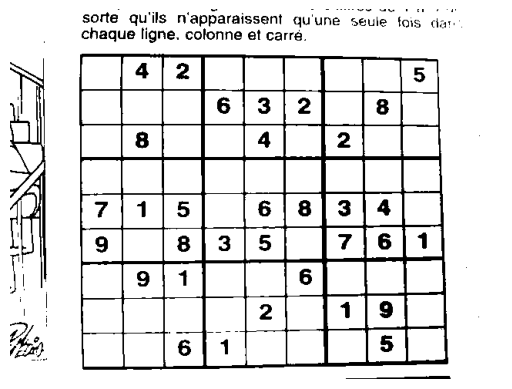

In [20]:
thresh = 256/2
threshold_img = threshold(image, 256/2)
display_image_grayscale(threshold_img)